# Symbolic Regression v. Gaussian Process Regression

This notebook directly compares the results from symbolic regression with Gaussian process regression and generates a plot.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as mse

## Symbolic Regression

In [2]:
prefix = "symreg/eqns_fold"
suffix = "_simplified.csv"

dflist = []

for i in np.arange(4):

    df = pd.read_csv(prefix + str(i) + suffix)
    dflist.append(df)

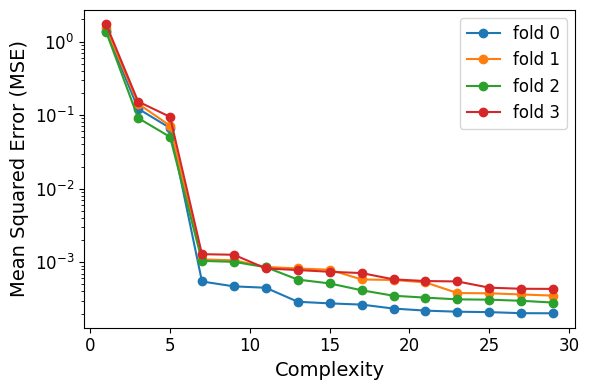

In [3]:
fig, ax1 = plt.subplots(figsize=(6, 4))

left, bottom, width, height = [0.5, 0.35, 0.39, 0.27]

for i, df in enumerate(dflist):
    ax1.plot(df["complexity"], df["loss"], label="fold " + str(i), marker="o")

ax1.set_yscale("log")
ax1.set_xlabel("Complexity", fontsize=14)
ax1.set_ylabel("Mean Squared Error (MSE)", fontsize=14)

ax1.tick_params(axis="x", labelsize=12)
ax1.tick_params(axis="y", labelsize=12)

ax1.legend(fontsize=12)

plt.tight_layout()

### Execute functions

In [4]:
alist = []
blist = []

for i, df in enumerate(dflist):

    print("Fold", i)
    eq = df.iloc[3]["equation"].split(";")
    print(eq)

    alist.append(eval(eq[1][5:]))
    blist.append(eval(eq[2][5:]))
    f = (
        "def wlf"
        + str(i)
        + "(dT, Tref, c, a, b):\n    return "
        + eq[0][3:]
        .replace("#1", "dT")
        .replace("#2", "Tref")
        .replace("#3", "a[c-1]")
        .replace("#4", "b[c-1]")
    )
    exec(f)

Fold 0
['f = (#4 * #1) / (#3 - #1)', ' p1 = [-105.405, -92.72447, -149.80933, -119.517136, -109.35384, -150.76743]', ' p2 = [9.0042715, 8.977725, 2.5047429, 5.7414947, 5.098243, 7.769681]']
Fold 1
['f = #3 * (#1 / (#1 + #4))', ' p1 = [-9.051867, -9.616367, -2.507802, -5.6778655, -5.040051, -8.720061]', ' p2 = [106.889725, 103.35292, 149.88333, 118.62041, 107.23512, 164.1112]']
Fold 2
['f = (#1 * #3) / (#4 + #1)', ' p1 = [-8.99006, -9.792899, -2.661326, -5.604228, -5.0765843, -7.4095144]', ' p2 = [105.54564, 108.77882, 153.97325, 117.19918, 108.7516, 137.26506]']
Fold 3
['f = (#1 * #4) / (#3 - #1)', ' p1 = [-105.88216, -100.30991, -151.69589, -118.31599, -110.47199, -153.69011]', ' p2 = [9.007306, 9.468485, 2.6034238, 5.65617, 5.142482, 8.026936]']


### Mean Squared Error

In [5]:
mselist = []

for f in np.arange(4):

    fold = pd.read_csv("data/WLF_data_folds.csv")
    train = fold[fold["fold"] != f]
    test = fold[fold["fold"] == f]

    predtrain = np.zeros(len(train))
    for i in range(len(train)):
        predtrain[i] = globals()["wlf" + str(f)](
            train.iloc[i]["dT"],
            train.iloc[i]["Tref"],
            int(train.iloc[i]["class"]),
            alist[f],
            blist[f],
        )

    predtest = np.zeros(len(test))
    for i in range(len(test)):
        predtest[i] = globals()["wlf" + str(f)](
            test.iloc[i]["dT"],
            test.iloc[i]["Tref"],
            int(test.iloc[i]["class"]),
            alist[f],
            blist[f],
        )

    msetrain = mse(train["log_aT"], predtrain)
    msetest = mse(test["log_aT"], predtest)

    mselist.append([f, msetrain, msetest])

In [6]:
srmse = pd.DataFrame(mselist, columns=["fold", "mse_train", "mse_test"])
srmse.to_csv("results/sr_mse.csv", index=False)
srmse.head()

,fold,mse_train,mse_test
0,0,0.000546,0.004106
1,1,0.001090,0.002472
2,2,0.001040,0.004828
3,3,0.001284,0.000928


In [7]:
print("Train:", srmse["mse_train"].mean(), "+/-", srmse["mse_train"].std())
print("Test:", srmse["mse_test"].mean(), "+/-", srmse["mse_test"].std())

Train: 0.000990167600523153 +/- 0.00031417726748718
Test: 0.0030837470681095796 +/- 0.00174249886900409


# Gaussian Process Regression

In [8]:
gpmse = pd.read_csv("results/gp_mse.csv")
gpmse.head()

,fold,mse_train,mse_test
0,0,0.000215,0.019902
1,1,0.000336,0.004540
2,2,0.000263,0.013482
3,3,0.000408,0.004614


In [9]:
print("Train:", gpmse["mse_train"].mean(), "+/-", gpmse["mse_train"].std())
print("Test:", gpmse["mse_test"].mean(), "+/-", gpmse["mse_test"].std())

Train: 0.00030547521541952503 +/- 8.448835220585738e-05
Test: 0.010634758280613325 +/- 0.007469422885810315


# Parity plot

In [10]:
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14

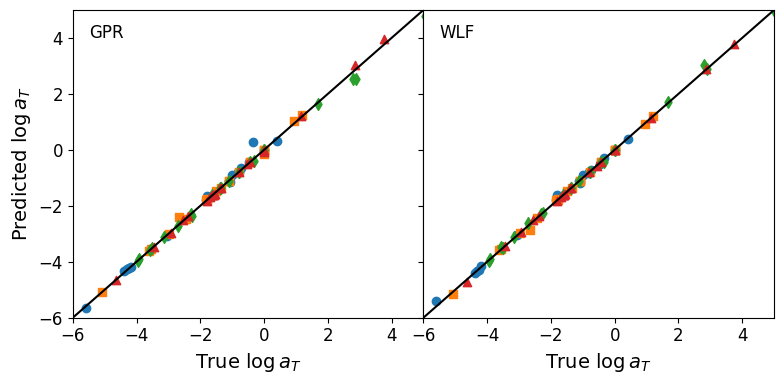

In [11]:
fig = plt.figure(figsize=(8, 4))
gs = fig.add_gridspec(1, 2, hspace=0, wspace=0)
ax1, ax2 = gs.subplots(sharey="row")

markerlist = ["o", "s", "d", "^"]

for f in np.arange(4):

    # Symbolic Regression
    fold = pd.read_csv("data/WLF_data_folds.csv")
    train = fold[fold["fold"] != f]
    test = fold[fold["fold"] == f]

    predtrain = np.zeros(len(train))
    for i in range(len(train)):
        predtrain[i] = globals()["wlf" + str(f)](
            train.iloc[i]["dT"],
            train.iloc[i]["Tref"],
            int(train.iloc[i]["class"]),
            alist[f],
            blist[f],
        )

    predtest = np.zeros(len(test))
    for i in range(len(test)):
        predtest[i] = globals()["wlf" + str(f)](
            test.iloc[i]["dT"],
            test.iloc[i]["Tref"],
            int(test.iloc[i]["class"]),
            alist[f],
            blist[f],
        )

    ax2.scatter(test["log_aT"], predtest, color=plt.cm.tab10(f), marker=markerlist[f])

    # Gaussian Process Regression
    dfpred = np.loadtxt("results/gp_test_f" + str(f) + ".csv")
    dfact = pd.read_csv("data/WLF_data_folds.csv")
    dfact = dfact[dfact["fold"] == f]

    ax1.scatter(dfact["log_aT"], dfpred, color=plt.cm.tab10(f), marker=markerlist[f])

# Parity lines
ax2.plot(np.linspace(-6, 5, 10), np.linspace(-6, 5, 10), "k")
ax1.plot(np.linspace(-6, 5, 10), np.linspace(-6, 5, 10), "k")

ax1.set_xlim(-6, 5)
ax2.set_xlim(-6, 5)
ax1.set_ylim(-6, 5)
ax2.set_ylim(-6, 5)

ax1.set_xlabel(r"True $\log a_T$")
ax2.set_xlabel(r"True $\log a_T$")
ax1.set_ylabel(r"Predicted $\log a_T$")

ax1.text(-5.5, 4, "GPR", fontsize=12)
ax2.text(-5.5, 4, "WLF", fontsize=12)

plt.tight_layout()
plt.savefig("figures/GPR_SR_Parity.jpeg", dpi=600)